## **Classificação de espécies de flores**
- O objetivo desse notebook será implementar e usar Machine Learning para classificação/identificação correta de três espécies diferentes de flores da família Iris a partir de um dataset público que contém seus dados. Quanto ao curso do DATA, esse notebook representa essencialmente o projeto final (com alterações porque não fui capaz de encontrar os arquivos originais propostos).

In [16]:
# Inclusão de bibliotecas necessárias;
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

# Modelos e instâncias do scikit-learn necessárias;
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### **# Carregamento do dataset**

In [ ]:
# Lê o arquivo .xlsx do dataset e carrega-o em um dataframe pandas;
df = pd.read_excel("/home/luish/VSCode/IC/Datasets/iris.xlsx")

# Imprime características gerais do dados para visualização;
df.info()
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


Com esse código, dá pra ver que não há valores nulos ou faltantes no dataset, então podemos pular a parte de pré-processamento de dados.
Com o info, sabemos que o dataset possui 5 colunas, comprimento e lárgura de sépalas, comprimento e largura de pétalas, e a espécie.

### **# Visualização dos dados / Analise exploratória**
Essa etapa é, tecnicamente, desnecessária se considerar puramente o intuito de treinar e testar o ML, mas é interessante de se fazer antes dos treinamentos.

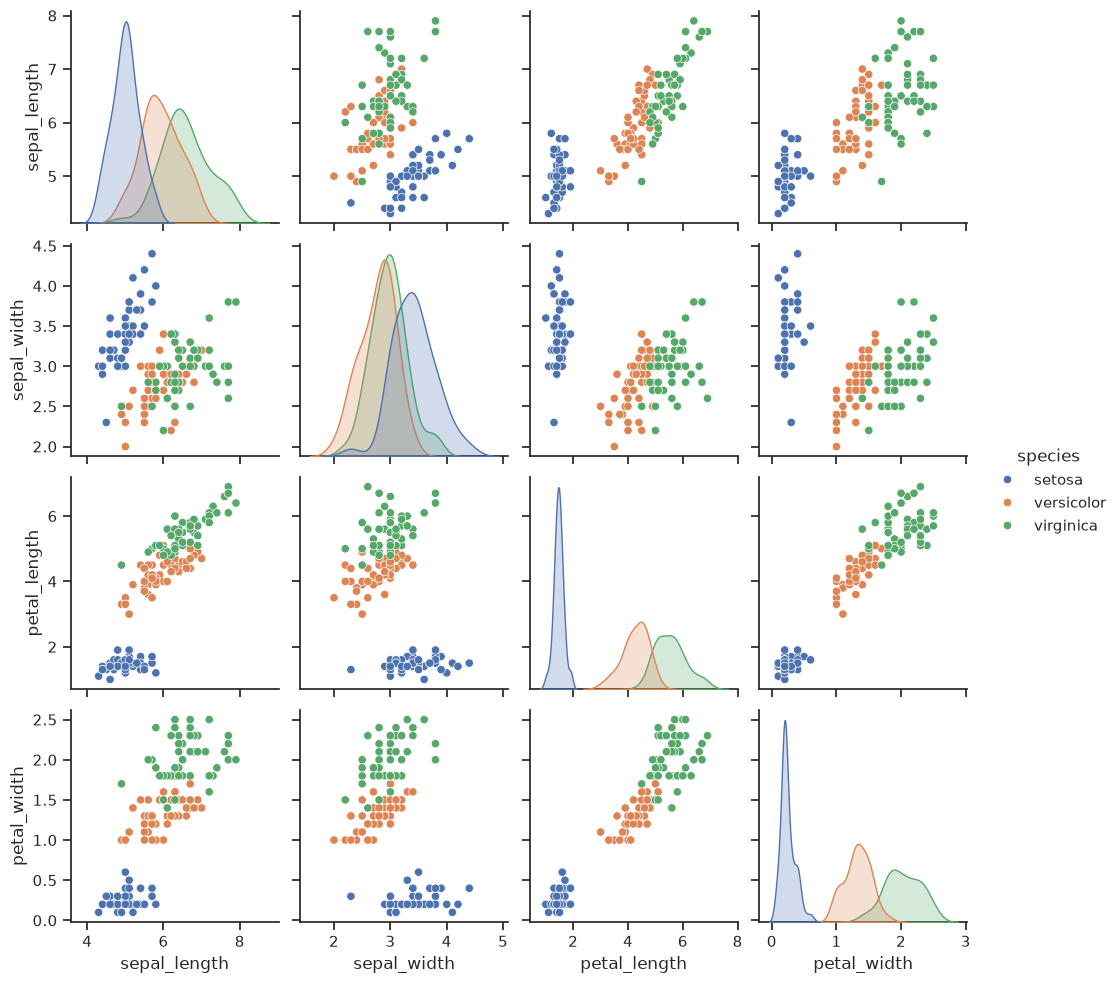

In [20]:
# Gráfico de Pares gerado pelo seaborn, cruza todas as colunas do dataframe, duas a duas, e colore os pontos de acordo com a espécie; 
# Muito útil pra ver as correlações e distribuições dos dados.
sns.pairplot(df, hue="species", palette="deep")
plt.show()

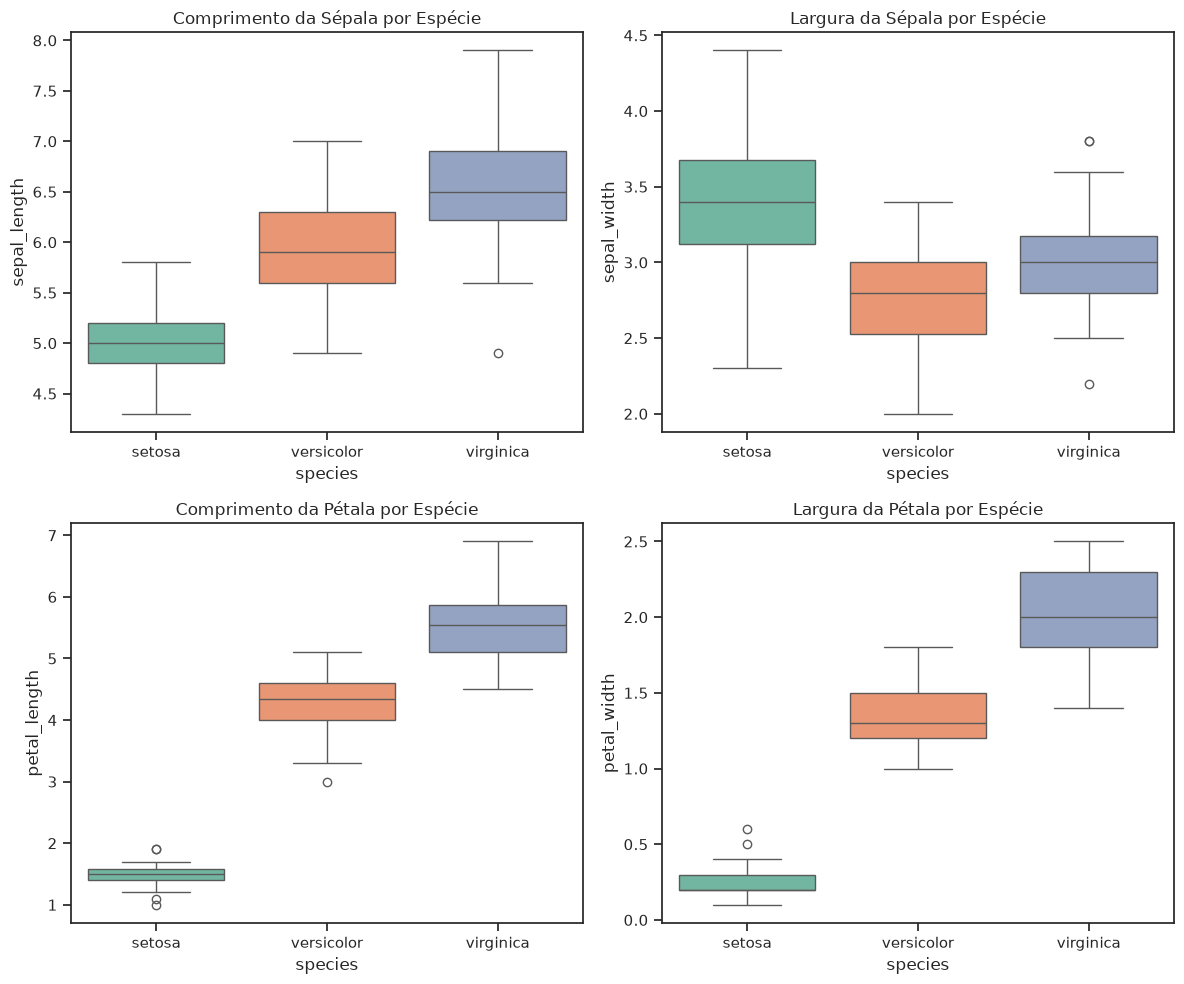

In [ ]:
# Boxplots gerados pelo Seaborn;
# Servem para análises estatísticas mais específicas por espécie;

# Grid 2x2 para 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Cria um boxplot para cada característica do dataset
sns.boxplot(
    ax=axes[0, 0],
    x="species",
    y="sepal_length",
    data=df,
    hue="species",
    palette="Set2",
    legend=False,
)
axes[0, 0].set_title("Comprimento da Sépala por Espécie")

sns.boxplot(
    ax=axes[0, 1],
    x="species",
    y="sepal_width",
    data=df,
    hue="species",
    palette="Set2",
    legend=False,
)
axes[0, 1].set_title("Largura da Sépala por Espécie")

sns.boxplot(
    ax=axes[1, 0],
    x="species",
    y="petal_length",
    data=df,
    hue="species",
    palette="Set2",
    legend=False,
)
axes[1, 0].set_title("Comprimento da Pétala por Espécie")

sns.boxplot(
    ax=axes[1, 1],
    x="species",
    y="petal_width",
    data=df,
    hue="species",
    palette="Set2",
    legend=False,
)
axes[1, 1].set_title("Largura da Pétala por Espécie")

# Ajusta o espaçamento para os títulos não se sobreporem
plt.tight_layout()
plt.show()



Com esses gráficos, podemos ver que há claras tendências entre as espécies de flores. O objetivo dessa análise é basicamente visualizar e validar a hipótese que a IA vai tentar resolver matematicamente. Por exemplo, é praticamente impossível confundir uma setosa com uma das outras espécies quando se analisa a largura e comprimento das pétalas.

### **# Treinamento**
Aqui, vamos de fato fazer o treinamento dos modelos utilizando os dados do dataset. Para isso, "escondemos" a coluna de species, já que eles não podem saber o resultado.

In [14]:
# X recebe o dataset sem a coluna de espécie (gabarito);
X = df.drop(columns="species")
# y contém apenas a coluna de espécies;
y = df["species"]

In [18]:
modelos = {
    "SVC": SVC(kernel="rbf", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
    print(f"{nome} - Acurácia Média: {scores.mean():.2%} (+/- {scores.std():.2%})")

SVC - Acurácia Média: 96.67% (+/- 2.11%)
Random Forest - Acurácia Média: 96.67% (+/- 2.11%)
KNN - Acurácia Média: 97.33% (+/- 2.49%)


Com essa seed e de acordo com o cross-validation, o modelo de maior acurácia foi o KNN, então, vamos rodar ele isoladamente para um diagnóstico final fazendo uma separação manual.

--- Relatório do KNN ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



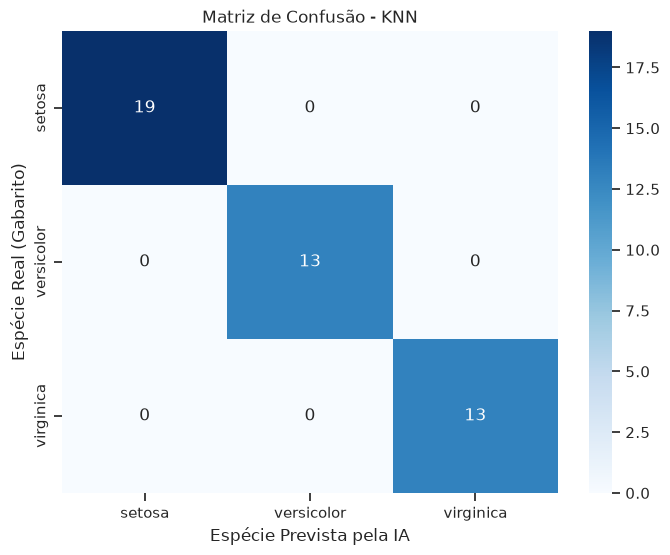

In [ ]:
# Usa a função de train_test_split para dividir automaticamente os dados entre treino e teste. (70% treino, 30% teste);
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instancia apenas o KNN, porque foi o vencedor no teste de acurácia. (Por pouco)
modelo_final = KNeighborsClassifier(n_neighbors=5)

# Treina o modelo usando a divisão de treino criada pelo train test split. 
modelo_final.fit(X_train, y_train)

# Gera as previsões e um relatório detalhado;
y_pred = modelo_final.predict(X_test)
print("--- Relatório do KNN ---")
print(classification_report(y_test, y_pred))

# Plota a matriz de confusão (visualização dos erros do modelo)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_final.classes_,
            yticklabels=modelo_final.classes_,
            annot_kws={"size": 14})

plt.title('Matriz de Confusão - KNN')
plt.ylabel('Espécie Real (Gabarito)')
plt.xlabel('Espécie Prevista pela IA')

plt.show()
            

### **# Resultado final**
Pelo incrível que pareça, o modelo nesse caso conseguiu acertar 100% dos casos de teste! Não necessariamente quer dizer que ele foi 100% preciso, já que pode ter tido sorte na seed e afins (vimos pelo cross-validation que ele não tem uma acurácia fixa de 100%, e é sujeito a erros).